___

# <font color= #f6c049> **Soda Pop Project: Variational Autoencoder 1** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_03/03/2026._

___

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# General
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Run on CPU
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout
from keras.optimizers import Adam
from keras import Model

# Loss Function
from tensorflow.keras.applications import VGG19
from tensorflow.keras import Model, Input

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import ops

In [15]:
train_ds = tf.data.Dataset.load('../data/processed/train_ds')
val_ds = tf.data.Dataset.load('../data/processed/val_ds')
test_ds = tf.data.Dataset.load('../data/processed/test_ds')

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, Model

input_shape = (64, 64, 3)
latent_dim = 128   # puedes cambiarlo

In [17]:
encoder_inputs = layers.Input(shape=input_shape)

# 64x64x3
x = layers.Conv2D(64, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D((2,2))(x)   # 32x32x64

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)   # 16x16x32

x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)   # 8x8x16

shape_before_flatten = tf.keras.backend.int_shape(x)

x = layers.Flatten()(x)

# Media y varianza
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [18]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [19]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(
    shape_before_flatten[1] *
    shape_before_flatten[2] *
    shape_before_flatten[3],
    activation='relu'
)(latent_inputs)

x = layers.Reshape((
    shape_before_flatten[1],
    shape_before_flatten[2],
    shape_before_flatten[3]
))(x)

# 8x8x16
x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)   # 16x16

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)   # 32x32

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)   # 64x64

decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

In [20]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        # Reconstruction loss
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(inputs, reconstruction),
                axis=(1,2)
            )
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        self.add_loss(recon_loss + kl_loss)
        return reconstruction

vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

In [21]:
vae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 261ms/step - loss: 2430.9509 - val_loss: 2203.7288
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - loss: 2094.5959 - val_loss: 2099.9836
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 266ms/step - loss: 1996.0819 - val_loss: 1997.2844
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - loss: 1942.6324 - val_loss: 1950.8906
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - loss: 1909.6582 - val_loss: 1922.8049
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - loss: 1876.8129 - val_loss: 1897.8792
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - loss: 1854.3622 - val_loss: 1883.8971
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - loss: 1847.5789 - val_loss: 1872.0289
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 288ms/step - loss: 1828.3182 - val_loss: 1850.6830
Epoch 10/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 290ms/step - loss: 1825.5175 - val_loss: 1858.8655
Epoch 11/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 291ms/step - loss: 1808.79

In [22]:
z_random = tf.random.normal((10, latent_dim))
generated_images = decoder.predict(z_random)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


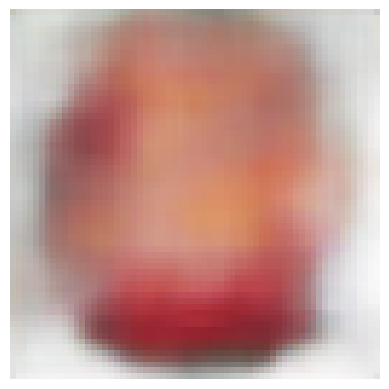

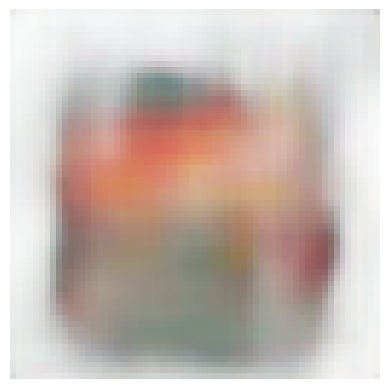

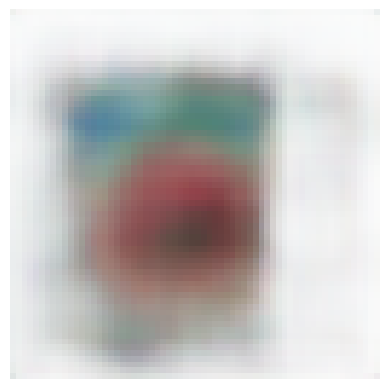

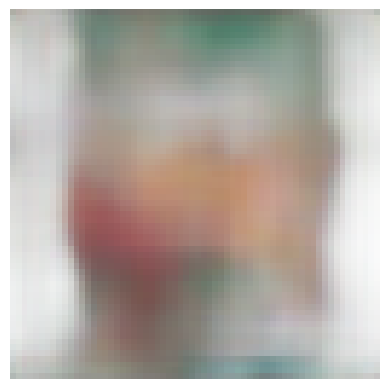

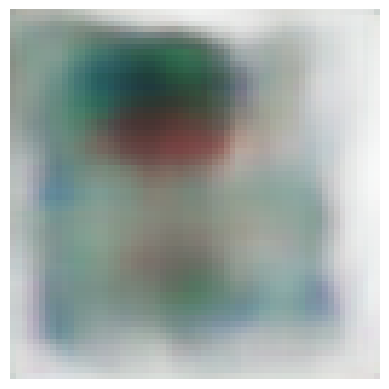

In [23]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.figure()
    plt.imshow(generated_images[i])
    plt.axis("off")
    plt.show()